# **Calculation of global tidal stress field models**

*L. Delaroque, 10 Apr. 2025*

Here is a wrapper that allows you to call commands from the open-source code *SatStress* v.0.1.2 (see the download link at [http://code.google.com/p/satstress](http://code.google.com/p/satstress)). The stress field simulation, as applied to icy satellites, is based on tidal potential theory (see Zane Selvans’ dissertation [here](https://zenodo.org/records/3455893); [Wahr et al. 2009](https://doi.org/10.1016/j.icarus.2008.11.002))), and is largely designed to support analyses comparing the global tidal stress field with observable surface tectonic features.
Publications that address the topic of tidal stress analysis and surface tectonics include:
- Titan: Burkhard et al. [Burkhard et al. 2022](https://www.sciencedirect.com/science/article/pii/S0019103521003559), [2023](https://doi.org/10.1016/j.icarus.2023.115764).
- Ganymede: Cameron et al. [Cameron et al. 2019](https://www.sciencedirect.com/science/article/pii/S0019103518300708?pes=vor&utm_source=sciencedirect_contenthosting&getft_integrator=sciencedirect_contenthosting), [2020](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2019JE005995). Further information on Ganymede’s tectonic features can be found in Cameron et al. [2018](https://www.sciencedirect.com/science/article/pii/S0019103517304657).
 

In [1]:
from SatStress.SatStress import *
import numpy as np
import matplotlib.pyplot as plt

To summarize, there are two main types of tidal forces that can be applied to satellites:
- Non-Synchronous Rotation (NSR), which, as the name suggests, is related to the satellite’s rotation not being synchronized with its orbit around the planet.
- Diurnal tides, which are time-varying forces caused by the satellite's orbital eccentricity.

For the calculation of the tidal Love number $k_2$, see the theory in [Tobie et al. 2005](https://doi.org/10.1016/j.icarus.2005.04.006).

According to [Vance et al. (2018)](https://agupubs.onlinelibrary.wiley.com/doi/10.1002/2017JE005341), the reference viscosity for the ice shell is $10^{13}$ Pa·s.

# Application to **Europa**

In [2]:
# Lines of code retrieved from code documentation
# The input template used here for Europa is the one supplied by default with the code
the_sat = Satellite(open("input/Europa.satellite"))
print('Information about Europa: ')
the_stresses = StressCalc([Diurnal(the_sat)]) # NSR(the_sat)
Tau = the_stresses.tensor(theta=np.pi/4.0, phi=np.pi/3.0, t=10000)
print("Tau [Pa]:\n", Tau)

Information about Europa: 
3.01174		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
3.54995		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+17		Viscosity of lower ice layer (Pa sec)
1e+11		Young's modulus for the rocky core
0.25		Poisson's ratio for the rocky core
3.8476		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.917		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
150		Thickness of fluid layer (km)
1		Density of fluid layer (g/cm^3)
1414.21		P-wave velocity in fluid layer (km/sec)
1561		Total radius of satellite (km)
8		Thickness of upper (cold) ice layer (km)
12		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
Love numbers k2:
 0.247740

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory


In [3]:
# Lines originally in file ‘test_nsr_diurnal.py’, retrieved and modified
the_sat = Satellite(open("input/Europa.satellite"))

# Create a StressCalc object, that calculates both the NSR and Diurnal stress
# stresses on the Satellite just instantiated:
the_stresses = StressCalc([Diurnal(the_sat), NSR(the_sat)])

# Do a series of calculations, varying all the inputs at each iteration
theta = 0.0  # latitude colatitude (in rad)
phi   = 0.0  # longitude (in rad)
t     = 0.0  # time or fraction of orbit (0=periapse, i.e., the closest orbital position to the planet)

# A list to store the calculation results in for later checking
# Quick reminder on the stress tensor components:
# • Ttt (τ_θθ) the north-south (latitudinal) component
# • Tpt (τ_φθ = τ_θφ) the shear component
# • Tpp (τ_φφ) the east-west (longitudinal) component
Taulist = [] # store the stress tensor

while the_stresses.stresses[1].Delta() > 0.01 and t < 2.0*np.pi/the_sat.mean_motion():
    print("""Tau(theta = %g, phi = %g, time = %g, Delta = %g) = """ % (np.degrees(theta), np.degrees(phi), t, the_stresses.stresses[1].Delta()))
    Taulist.append(the_stresses.tensor(theta=theta, phi=phi, t=0))
    print( Taulist[-1], "\n")
    theta = theta + np.pi/23.0
    phi   = phi   + np.pi/11.0
    t     = t     + (np.pi/11.0)/the_sat.mean_motion()

    # Re-construct the NSR stress (and the_stresses StressCalc object)
    # changing the forcing period, so that we can have the NSR stresses
    # vary with each iteration too.
    the_sat.nsr_period = the_sat.nsr_period / 1.5
    the_stresses = StressCalc([Diurnal(the_sat), NSR(the_sat)])

3.01174		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
3.54995		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+17		Viscosity of lower ice layer (Pa sec)
1e+11		Young's modulus for the rocky core
0.25		Poisson's ratio for the rocky core
3.8476		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.917		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
150		Thickness of fluid layer (km)
1		Density of fluid layer (g/cm^3)
1414.21		P-wave velocity in fluid layer (km/sec)
1561		Total radius of satellite (km)
8		Thickness of upper (cold) ice layer (km)
12		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
Love numbers k2:
 0.24774039 -0.00001285
3.01174		Mea

At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x1008b6d2f
#1  0x1008b78d7
#2  0x1008b81a7
#3  0x1009a70a3
#4  0x1009a75bf
#5  0x10025e53f
#6  0x10026373b
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x1051f2d2f
#1  0x1051f38d7
#2  0x1051f41a7
#3  0x1052e30a3
#4  0x1052e35bf
#5  0x104b9a53f
#6  0x104b9f73b
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No 

Love numbers k2:
 0.24774039 -0.00001285
3.01174		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
7.12559e+09		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+17		Viscosity of lower ice layer (Pa sec)
1.1996e+08		Young's modulus for the rocky core
0.4995		Poisson's ratio for the rocky core
3.8476		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.917		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
150		Thickness of fluid layer (km)
1		Density of fluid layer (g/cm^3)
1414.21		P-wave velocity in fluid layer (km/sec)
1561		Total radius of satellite (km)
8		Thickness of upper (cold) ice layer (km)
12		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
L

At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x1008c2d2f
#1  0x1008c38d7
#2  0x1008c41a7
#3  0x1009b30a3
#4  0x1009b35bf
#5  0x10026a53f
#6  0x10026f73b
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x1012e2d2f
#1  0x1012e38d7
#2  0x1012e41a7
#3  0x1013d30a3
#4  0x1013d35bf
#5  0x100c8a53f
#6  0x100c8f73b
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No 

Plotting the global tidal stress field map

At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x1029a2d2f
#1  0x1029a38d7
#2  0x1029a41a7
#3  0x102a930a3
#4  0x102a935bf
#5  0x10234a53f
#6  0x10234f73b
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
/var/folders/63/pkg4dhb14439_yj1mzhxdg0m0000gn/T/ipykernel_88463/3175102466.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Map of the maximum principal stress $\sigma_1$ field for Europa\n(m = 0; periapse)")
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x10323ed2f
#1  0x10323f8d7
#2  0x1032401a7
#3  0x10332f0a3
#4  0x103

3.01174		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
3.54995		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+17		Viscosity of lower ice layer (Pa sec)
1e+11		Young's modulus for the rocky core
0.25		Poisson's ratio for the rocky core
3.8476		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.917		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
150		Thickness of fluid layer (km)
1		Density of fluid layer (g/cm^3)
1414.21		P-wave velocity in fluid layer (km/sec)
1561		Total radius of satellite (km)
8		Thickness of upper (cold) ice layer (km)
12		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
Love numbers k2:
 0.24774039 -0.00001285
3.01174		Mea

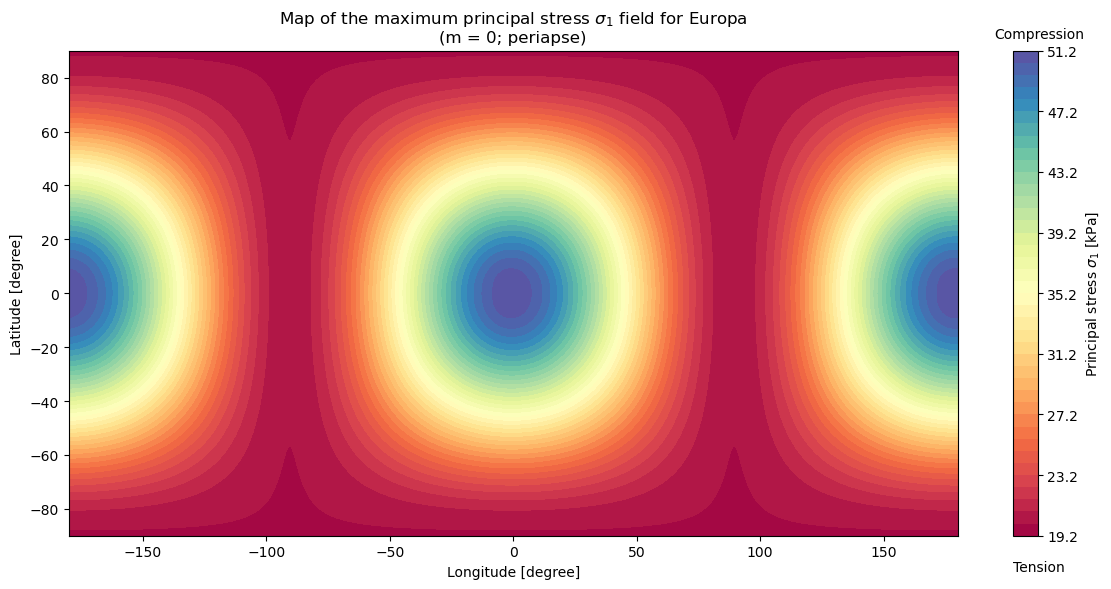

In [4]:
sat = Satellite(open("input/Europa.satellite"))
stresses = StressCalc([Diurnal(sat), NSR(sat)])

latitudes = np.linspace(-90, 90, 181)     
longitudes = np.linspace(-180, 180, 361)  

sigma1_grid = np.zeros((len(latitudes), len(longitudes)))

t = 0  # another ex. np.pi/2 / sat.mean_motion() can be used

for i, lat in enumerate(latitudes):
    for j, lon in enumerate(longitudes):
        theta = np.radians(90 - lat)   # colatitude
        phi = np.radians(lon)
        tau = stresses.tensor(theta=theta, phi=phi, t=t)
        
        # Compute the principal stress tensor
        eigvals = np.linalg.eigvalsh(tau)  
        sigma1_grid[i, j] = np.max(eigvals)

plt.figure(figsize=(12, 6))
plt.contourf(longitudes, latitudes, sigma1_grid/1e3, levels=40, cmap="Spectral")
cb = plt.colorbar(label=r"Principal stress $\sigma_1$ [kPa]")
cb.ax.text(1.05, 1.02, "Compression", transform=cb.ax.transAxes, ha='center', va='bottom', fontsize=10)
cb.ax.text(1.05, -0.05, "Tension", transform=cb.ax.transAxes, ha='center', va='top', fontsize=10)
plt.xlabel("Longitude [degree]")
plt.ylabel("Latitude [degree]")
plt.title("Map of the maximum principal stress $\sigma_1$ field for Europa\n(m = 0; periapse)")
plt.tight_layout()
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/var/folders/63/pkg4dhb14439_yj1mzhxdg0m0000gn/T/ipykernel_88463/2512994067.py:30: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle('Map of the principal stress $\sigma_1$ field for Europa', fontsize=16, fontweight='bold')
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x103172d2f
#1  0x1031738d7
#2  0x1031741a7
#3  0x1032630a3
#4  0x1032635bf
#5  0x102b1a53f
#6  0x102b1f73b
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of f

3.01174		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
3.54995		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+17		Viscosity of lower ice layer (Pa sec)
1e+11		Young's modulus for the rocky core
0.25		Poisson's ratio for the rocky core
3.8476		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.917		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
150		Thickness of fluid layer (km)
1		Density of fluid layer (g/cm^3)
1414.21		P-wave velocity in fluid layer (km/sec)
1561		Total radius of satellite (km)
8		Thickness of upper (cold) ice layer (km)
12		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
Love numbers k2:
 0.24774039 -0.00001285
3.01174		Mea

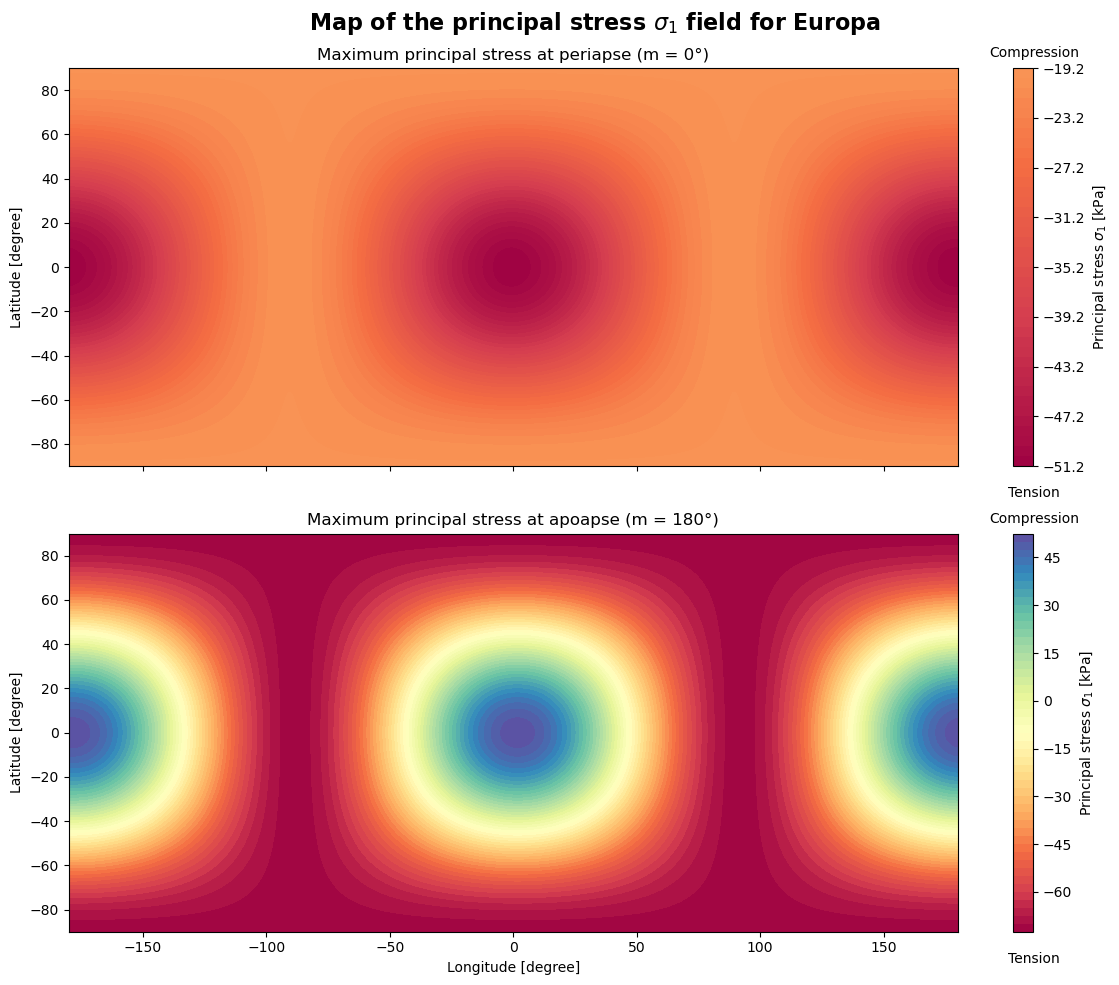

In [5]:
sat = Satellite(open("input/Europa.satellite"))
stresses = StressCalc([Diurnal(sat), NSR(sat)])

latitudes = np.linspace(-90, 90, 181)      
longitudes = np.linspace(-180, 180, 361)  

sigma1_peri = np.zeros((len(latitudes), len(longitudes)))
sigma1_apo  = np.zeros((len(latitudes), len(longitudes)))

def compute_sigma1_grid(t):
    sigma_grid = np.zeros((len(latitudes), len(longitudes)))
    for i, lat in enumerate(latitudes):
        for j, lon in enumerate(longitudes):
            theta = np.radians(90 - lat)   # colatitude
            phi = np.radians(lon)
            tau = stresses.tensor(theta=theta, phi=phi, t=t)
            eigvals = np.linalg.eigvalsh(tau)
            sigma_grid[i, j] = np.max(eigvals)
    return sigma_grid

# Compute σ₁ for t = 0 (periapse) et t = π / n (apoapse)
sigma1_peri = compute_sigma1_grid(t=0)
sigma1_apo  = compute_sigma1_grid(t=np.pi / sat.mean_motion())

fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Map of the principal stress $\sigma_1$ field for Europa', fontsize=16, fontweight='bold')

vmin = min(np.min(sigma1_peri), np.min(sigma1_apo)) / 1e3
vmax = max(np.max(sigma1_peri), np.max(sigma1_apo)) / 1e3

# vmin = -50  # kPa
# vmax = 50   # kPa

# Periapse
c1 = axs[0].contourf(longitudes, latitudes, -sigma1_peri/1e3, levels=50, cmap="Spectral", vmin=vmin, vmax=vmax)
cb1 = fig.colorbar(c1, ax=axs[0], orientation='vertical', label=r"Principal stress $\sigma_1$ [kPa]")
cb1.ax.text(1.05, 1.02, "Compression", transform=cb1.ax.transAxes, ha='center', va='bottom', fontsize=10)
cb1.ax.text(1.05, -0.05, "Tension", transform=cb1.ax.transAxes, ha='center', va='top', fontsize=10)
axs[0].set_ylabel("Latitude [degree]")
axs[0].set_title("Maximum principal stress at periapse (m = 0°)")

# Apoapse
c2 = axs[1].contourf(longitudes, latitudes, -sigma1_apo/1e3, levels=50, cmap="Spectral")
cb2 = fig.colorbar(c2, ax=axs[1], orientation='vertical', label=r"Principal stress $\sigma_1$ [kPa]")
cb2.ax.text(1.05, 1.02, "Compression", transform=cb2.ax.transAxes, ha='center', va='bottom', fontsize=10)
cb2.ax.text(1.05, -0.05, "Tension", transform=cb2.ax.transAxes, ha='center', va='top', fontsize=10)
axs[1].set_xlabel("Longitude [degree]")
axs[1].set_ylabel("Latitude [degree]")
axs[1].set_title("Maximum principal stress at apoapse (m = 180°)")

plt.tight_layout()
plt.savefig('./maximum_sigma1_Europa.png', format='PNG')
plt.savefig('./maximum_sigma1_Europa.pdf', format='PDF')
plt.show()


# Application to **Titan**

In [6]:
the_sat = Satellite(open("input/Titan.satellite"))
# Only the parameters for the diurnal tidal stress is displayed
the_stresses = StressCalc([Diurnal(the_sat)]) # NSR(the_sat)
Tau = the_stresses.tensor(theta=np.pi/4.0, phi=np.pi/3.0, t=10000)
print("Tau ", Tau)

2.02087		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
15.9482		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+14		Viscosity of lower ice layer (Pa sec)
1e+11		Young's modulus for the rocky core
0.25		Poisson's ratio for the rocky core
2.45		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.951		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
178		Thickness of fluid layer (km)
1.07		Density of fluid layer (g/cm^3)
1367.17		P-wave velocity in fluid layer (km/sec)
2575		Total radius of satellite (km)
110		Thickness of upper (cold) ice layer (km)
1		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
Love numbers k2:
 0.41206276 -0.00005188
Tau  [[-10

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory


In [7]:
def true_anomaly_to_time(f_deg, e, mean_motion):
    """
    Converts a true anomaly (in degrees) into orbital time (in seconds)
    for an elliptical orbit given by its eccentricity e and its mean motion.

    Parameters:
    - f_deg: true anomaly in degrees (0° = periapse, 90° = post-periapse, 180° = apopase, 270° = post-apoapse)
        - e: orbital eccentricity
    - mean_motion: mean angular velocity n (rad/s)
    
    Return:
    - t: orbital time since perigee (sec)
    """
    f_rad = np.radians(f_deg)

    # Calculation of the eccentric anomaly E from fraction orbit f
    cos_E = (e + np.cos(f_rad)) / (1 + e * np.cos(f_rad))
    E = np.arccos(np.clip(cos_E, -1.0, 1.0))  # sécurité avec clip

    # Sign adjustment for f > 180°
    if f_deg > 180:
        E = 2 * np.pi - E

    # Mean anomaly (better for Titan as 1 Tiday day is 15.95 Earth days (not exactly 16 Earth days)
    M = E - e * np.sin(E)

    # Orbital time t = M / n
    t = M / mean_motion
    return t


At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x1026a2d2f
#1  0x1026a38d7
#2  0x1026a41a7
#3  0x1027930a3
#4  0x1027935bf
#5  0x10204a53f
#6  0x10204f73b


2.02087		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
15.9482		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+14		Viscosity of lower ice layer (Pa sec)
1e+11		Young's modulus for the rocky core
0.25		Poisson's ratio for the rocky core
2.45		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.951		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
178		Thickness of fluid layer (km)
1.07		Density of fluid layer (g/cm^3)
1367.17		P-wave velocity in fluid layer (km/sec)
2575		Total radius of satellite (km)
110		Thickness of upper (cold) ice layer (km)
1		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
Love numbers k2:
 0.41206276 -0.00005188


<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/var/folders/63/pkg4dhb14439_yj1mzhxdg0m0000gn/T/ipykernel_88463/3098733481.py:37: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Map of the maximum principal stress $\sigma_1$ at periapse (m = {f_deg}°)")
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x102e2ad2f
#1  0x102e2b8d7
#2  0x102e2c1a7
#3  0x102f1b0a3
#4  0x102f1b5bf
#5  0x1027d253f
#6  0x1027d773b


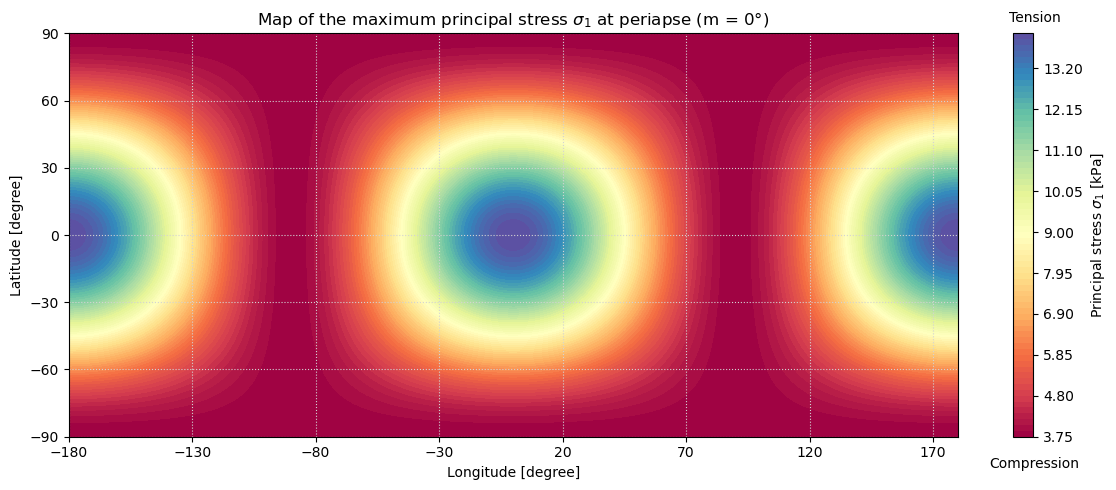

In [8]:
sat = Satellite(open("input/Titan.satellite"))

stresses = StressCalc([Diurnal(sat), NSR(sat)])

latitudes = np.linspace(-90, 90, 181)      # 1° space-step
longitudes = np.linspace(-180, 180, 361)   # 1° space-step


sigma1_grid = np.zeros((len(latitudes), len(longitudes)))

# For apoapse: np.pi/2 / sat.mean_motion(), periapse: 0
f_deg = 0
t = true_anomaly_to_time(f_deg, 0.0288, sat.mean_motion())  

for i, lat in enumerate(latitudes):
    for j, lon in enumerate(longitudes):
        theta = np.radians(90 - lat)   # colatitude
        phi = np.radians(lon)
        tau = stresses.tensor(theta=theta, phi=phi, t=t)
        
        # Calculation of the principal stress tensor
        eigvals = np.linalg.eigvalsh(tau) 
        sigma1_grid[i, j] = np.max(eigvals)

plt.figure(figsize=(12, 5))
plt.contourf(longitudes, latitudes, sigma1_grid/1e3, levels=80, cmap="Spectral")
cb = plt.colorbar(label=r"Principal stress $\sigma_1$ [kPa]")
cb.ax.text(1.05, 1.02, "Tension", transform=cb.ax.transAxes, ha='center', va='bottom', fontsize=10)
cb.ax.text(1.05, -0.05, "Compression", transform=cb.ax.transAxes, ha='center', va='top', fontsize=10)

plt.xticks(np.arange(-180, 181, 50))
plt.yticks(np.arange(-90, 91, 30))
plt.grid(True, linestyle=':', color='lightgray')

plt.xlabel("Longitude [degree]")
plt.ylabel("Latitude [degree]")
plt.title(f"Map of the maximum principal stress $\sigma_1$ at periapse (m = {f_deg}°)")
plt.tight_layout()
plt.savefig('./maximum_sigma1_Titan_0.png', format='PNG')
plt.show()

In [9]:
k2_real =  0.616  
k2_imag =  0.082        

k2_mod = np.sqrt(k2_real**2 + k2_imag**2)

Q_inv = k2_imag / k2_mod
Q = k2_mod / k2_imag

print(f"Q = {Q:.3f}")
print(f"Q⁻¹ = {Q_inv:.5f}")

Q = 7.578
Q⁻¹ = 0.13195


2.02111		Mean Density of Satellite (g/cm^3)
1		Rheology (1=Maxwell, 0=elastic)
15.9482		Forcing period (earth days, 86400 seconds)
1e+22		Viscosity of upper ice layer (Pa sec)
1e+14		Viscosity of lower ice layer (Pa sec)
1e+11		Young's modulus for the rocky core
0.25		Poisson's ratio for the rocky core
2.405		Density of the rocky core (g/cm^3)
9.27847e+09		Young's modulus for ice
0.330437		Poisson's ratio for ice
0.933		Density of ice
1		Decoupling fluid layer (e.g. global ocean)? (1=yes, 0=no)
1		Thickness of fluid layer (km)
1.172		Density of fluid layer (g/cm^3)
1306.32		P-wave velocity in fluid layer (km/sec)
2576		Total radius of satellite (km)
245		Thickness of upper (cold) ice layer (km)
1		Thickness of lower (warm) ice layer (km)
165		Total number of calculation nodes
3		Number of density discontinuities
154		Node number of innermost boundary
161		Node number of 2nd innermost boundary
163		Node number of 3rd innermost boundary
Love numbers k2:
 0.37233484 -0.00004216


<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/var/folders/63/pkg4dhb14439_yj1mzhxdg0m0000gn/T/ipykernel_88463/713124851.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Map of the maximum principal stress $\sigma_1$ at periapse (m = {f_deg}°)")
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
At line 19 of file love.f (unit = 10)
Fortran runtime error: Cannot open file 'in.love': No such file or directory

Error termination. Backtrace:
#0  0x10156ed2f
#1  0x10156f8d7
#2  0x1015701a7
#3  0x10165f0a3
#4  0x10165f5bf
#5  0x100f1653f
#6  0x100f1b73b


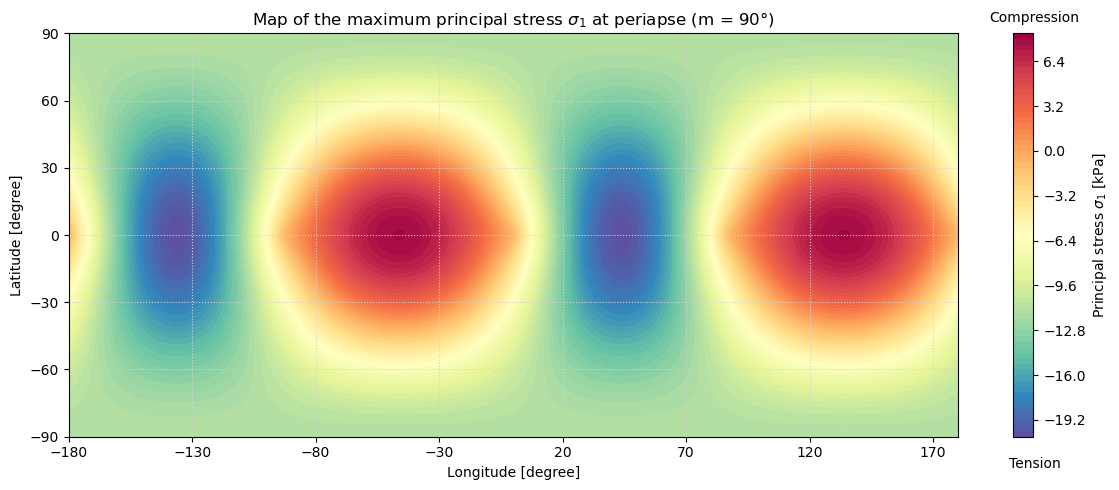

In [11]:
sat = Satellite(open("input/Titan_Vance2018.satellite"))

stresses = StressCalc([Diurnal(sat), NSR(sat)])

latitudes = np.linspace(-90, 90, 181)      
longitudes = np.linspace(-180, 180, 361)   

sigma1_grid = np.zeros((len(latitudes), len(longitudes)))

# Orbital time / fraction of orbit
f_deg = 90
t = true_anomaly_to_time(f_deg, 0.0288, sat.mean_motion())  # For apoapse: t = np.pi/2 / sat.mean_motion(), periapse: t = 0

for i, lat in enumerate(latitudes):
    for j, lon in enumerate(longitudes):
        theta = np.radians(90 - lat)   # colatitude
        phi = np.radians(lon)
        tau = stresses.tensor(theta=theta, phi=phi, t=t)
        
        eigvals = np.linalg.eigvalsh(tau)  # valeurs propres (réelles et triées)
        sigma1_grid[i, j] = np.max(eigvals)
sigma1_grid = -sigma1_grid

plt.figure(figsize=(12, 5))
plt.contourf(longitudes, latitudes, sigma1_grid/1e3, levels=80, cmap="Spectral_r")
cb = plt.colorbar(label=r"Principal stress $\sigma_1$ [kPa]")
cb.ax.text(1.05, 1.02, "Compression", transform=cb.ax.transAxes, ha='center', va='bottom', fontsize=10)
cb.ax.text(1.05, -0.05, "Tension", transform=cb.ax.transAxes, ha='center', va='top', fontsize=10)

plt.xticks(np.arange(-180, 181, 50))
plt.yticks(np.arange(-90, 91, 30))
plt.grid(True, linestyle=':', color='lightgray')

plt.xlabel("Longitude [degree]")
plt.ylabel("Latitude [degree]")
plt.title(f"Map of the maximum principal stress $\sigma_1$ at periapse (m = {f_deg}°)")
plt.tight_layout()
# plt.savefig('../maximum_sigma1_Titan_90.png', format='PNG', dpi=1200)
plt.show()

In [ ]:
sat = Satellite(open("input/Titan.satellite"))

stresses = StressCalc([Diurnal(sat), NSR(sat)])

latitudes = np.linspace(-90, 90, 181)      # 1° space-step
longitudes = np.linspace(-180, 180, 361)   # 1° space-step

sigma1_grid = np.zeros((len(latitudes), len(longitudes)))

# Orbital time / fraction of orbit
f_deg = 90
t = true_anomaly_to_time(f_deg, 0.0288, sat.mean_motion())  # For apoapse: t = np.pi/2 / sat.mean_motion(), periapse: t = 0

for i, lat in enumerate(latitudes):
    for j, lon in enumerate(longitudes):
        theta = np.radians(90 - lat)   # colatitude
        phi = np.radians(lon)
        tau = stresses.tensor(theta=theta, phi=phi, t=t)
        
        # Calculation of the principal stress
        eigvals = np.linalg.eigvalsh(tau)  # valeurs propres (réelles et triées)
        sigma1_grid[i, j] = np.max(eigvals)
# Inversion du signe pour avoir tension < 0 et compression > 0
sigma1_grid = -sigma1_grid

longitudes_W = (longitudes + 360) % 360
sort_idx = np.argsort(longitudes_W)
longitudes_W_sorted = longitudes_W[sort_idx]
sigma1_grid_plot_sorted = sigma1_grid[:, sort_idx]


plt.figure(figsize=(12, 5))
plt.contourf(
    longitudes_W_sorted,
    latitudes,
    sigma1_grid_plot_sorted/1e3,  # Conversion Pa → kPa
    levels=80,
    cmap="Spectral_r",
    vmin=-20, vmax=10  
)
plt.gca().invert_xaxis()

cb = plt.colorbar(label=r"Principal stress $\sigma_1$ [kPa]")
cb.ax.text(1.05, 1.02, "Compression", transform=cb.ax.transAxes, ha='center', va='bottom', fontsize=10)
cb.ax.text(1.05, -0.05, "Tension", transform=cb.ax.transAxes, ha='center', va='top', fontsize=10)

plt.xticks(ticks=np.arange(0, 361, 60),
           labels=[f"{lon}°W" for lon in np.arange(0, 361, 60)])
plt.yticks(np.arange(-90, 91, 30))
plt.grid(True, linestyle=':', color='lightgray')

plt.xticks(ticks=np.arange(0, 361, 60),
           labels=[f"{lon}°W" for lon in np.arange(0, 361, 60)])

lat_ticks = np.arange(-90, 91, 30)
lat_labels = [f"{abs(lat)}°{'S' if lat < 0 else ('N' if lat > 0 else '')}" for lat in lat_ticks]
plt.yticks(ticks=lat_ticks, labels=lat_labels)

plt.xlabel("Longitude [degree]")
plt.ylabel("Latitude [degree]")
plt.title(f"Map of the maximum principal stress $\\sigma_1$ at periapse (m = {f_deg}°)")
plt.tight_layout()
plt.savefig('./maximum_sigma1_Titan_270.png', format='PNG', dpi=1200)
plt.show()
